# Collections – Practice Exercises

This notebook contains hands-on exercises to practice Python collections and
data-structure patterns, following the ideas from `g_collections.ipynb`.

For each exercise:

- Read the description carefully.
- Implement your solution in the provided code cell (look for `# TODO`).
- Add small tests or printouts at the bottom of the cell to verify behavior.


### Contents

- [Exercise 1 – Complexity Warmup](#exercise-1--complexity-warmup)
- [Exercise 2 – Queue and Stack with deque](#exercise-2--queue-and-stack-with-deque)
- [Exercise 3 – Sliding Window with deque](#exercise-3--sliding-window-with-deque)
- [Exercise 4 – Grouping with defaultdict](#exercise-4--grouping-with-defaultdict)
- [Exercise 5 – Frequency Counting with Counter](#exercise-5--frequency-counting-with-counter)
- [Exercise 6 – Simple LRU Cache with OrderedDict](#exercise-6--simple-lru-cache-with-ordereddict)
- [Exercise 7 – Min-Heap Priority Queue](#exercise-7--min-heap-priority-queue)
- [Exercise 8 – Top-k Elements with heapq](#exercise-8--top-k-elements-with-heapq)
- [Exercise 9 – Build Graph Adjacency List](#exercise-9--build-graph-adjacency-list)
- [Exercise 10 – BFS and DFS on a Graph](#exercise-10--bfs-and-dfs-on-a-graph)
- [Exercise 11 – Shortest Path with networkx (optional)](#exercise-11--shortest-path-with-networkx-optional)
- [Exercise 12 – Range Query with bisect](#exercise-12--range-query-with-bisect)
- [Exercise 13 – Weighted Random Choice with bisect](#exercise-13--weighted-random-choice-with-bisect)
- [Exercise 14 – SortedList for Running Median (optional)](#exercise-14--sortedlist-for-running-median-optional)
- [Exercise 15 – SortedDict Order Book Sketch (optional)](#exercise-15--sorteddict-order-book-sketch-optional)


In [33]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')

## Exercise 1 – Complexity Warmup

**Goal**: Get an intuition for how different core operations scale.

**Requirements**:

- Write a function `time_operations(n: int)` that:
  - Builds a list of `n` integers and times `pop(0)` in a loop until empty.
  - Builds a `deque` of `n` integers and times `popleft()` in a loop until empty.
  - Prints the two timings in a readable format.
- Call `time_operations` for at least two values of `n` (e.g. 10_000 and 50_000).

**Hint**: Use `time.perf_counter()` for timing.


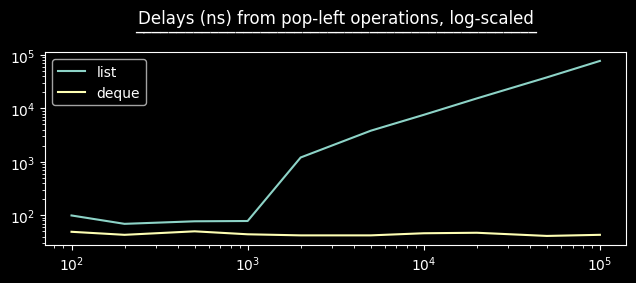

In [41]:
# Exercise 1 – implement time_operations(n)

import time, pandas
from collections import deque
from typing import Callable

def time_operations(n: int) -> None:
    """Compare list.pop(0) vs deque.popleft() for n elements.

    TODO: fill in the timing logic.
    """
    
    n = int(n)
    delay_list = delay_deque = 0
    my_list = list(range(n))
    my_deque = deque(range(n))
    # TODO: build list, time pop(0) in a loop
    while (len(my_list) > 0):
        t = time.perf_counter()
        my_list.pop(0)
        delay_list += int((time.perf_counter() - t) * 1e9)
    # TODO: build deque, time popleft() in a loop
    while (len(my_deque) > 0):
        t = time.perf_counter()
        my_deque.popleft()
        delay_deque += int((time.perf_counter() - t) * 1e9)

    return n, delay_list / n, delay_deque / n

# Demo calls (uncomment after implementing):
result = {"list": 0, "deque": 0}
prompt = "Average pop-left delays for \"n = {}\"" \
         " ... List: {:.0f} ns, Deque: {:.0f} ns"
sizes = [1e2, 2e2, 5e2, 1e3, 2e3, 5e3, 1e4, 2e4, 5e4, 1e5]
results = {int(n): result.copy() for n in sizes}
for size, result in results.items():
    n, d1, d2 = time_operations(size)
    result.update(list = int(d1), deque = int(d2))

df = pandas.DataFrame.from_dict(results, orient = "index")
title = "Delays (ns) from pop-left operations, log-scaled"
title = title + "\n" + "\u203E" * int(len(title))
df.plot(figsize = (7.5, 2.5), logx = True, logy = True, title = title);

## Exercise 2 – Queue and Stack with deque

**Goal**: Implement a simple FIFO queue and LIFO stack using `collections.deque`.

**Requirements**:

- Implement:
  - `enqueue(queue: deque[int], value: int) -> None`
  - `dequeue(queue: deque[int]) -> int`
  - `push(stack: deque[int], value: int) -> None`
  - `pop(stack: deque[int]) -> int`
- Show a small demo that enqueues/Dequeues and pushes/pops values.

**Hint**: For a queue, use `append` and `popleft`. For a stack, use `append` and `pop`.


In [54]:
# Exercise 2 – queue and stack helpers

from collections import deque
from typing import Deque

def enqueue(queue: Deque[int], value: int) -> None: queue.append(value)
def dequeue(queue: Deque[int]) -> int: return queue.popleft()
def push(stack: Deque[int], value: int) -> None: stack.appendleft(value)
def pop_stack(stack: Deque[int]) -> int: return stack.popleft()

# Demo (after implementing):
N = 5

print(f"Queue at start: {list(queue := deque())}")
for n in range(N):
    enqueue(queue, n)
    print(f"After enqueuing \"{n}\":", list(queue), "<==")
queue = [dequeue(queue) for _ in range(N)]
print("After dequeuing everything:", "<==", queue)

print(f"Stack at start: {list(stack := deque())}")
for n in range(N):
    push(stack, n)
    print(f"After pushing \"{n}\":", '==>', list(stack))
stack = [pop_stack(stack) for _ in range(N)]
print("After popping everything:", "<==", stack)

Queue at start: []
After enqueuing "0": [0] <==
After enqueuing "1": [0, 1] <==
After enqueuing "2": [0, 1, 2] <==
After enqueuing "3": [0, 1, 2, 3] <==
After enqueuing "4": [0, 1, 2, 3, 4] <==
After dequeuing everything: <== [0, 1, 2, 3, 4]
Stack at start: []
After pushing "0": ==> [0]
After pushing "1": ==> [1, 0]
After pushing "2": ==> [2, 1, 0]
After pushing "3": ==> [3, 2, 1, 0]
After pushing "4": ==> [4, 3, 2, 1, 0]
After popping everything: <== [4, 3, 2, 1, 0]


## Exercise 3 – Sliding Window with deque

**Goal**: Maintain a fixed-size sliding window and compute a rolling average.

**Requirements**:

- Implement a class `RollingAverage` with:
  - Constructor `__init__(self, window: int)`.
  - Method `add(value: float) -> float` that:
    - Adds `value` to the window.
    - Returns the average of values currently in the window.
- Use a `deque` with `maxlen=window` internally.

**Hint**: You can keep a running sum to avoid re-summing the whole window each time.


In [64]:
# Exercise 3 – implement RollingAverage

from collections import deque
from typing import Deque

class RollingAverage(deque):
    def __init__(self, window: int):
        super().__init__(maxlen = window)

    def add(self, value: float) -> float:
        self.appendleft(value)
        return sum(self) / self.maxlen

    def __repr__(self):
        return str(list(self))

# Demo idea:
ra = RollingAverage(5)
for x in range(0, 50, 3):
    before = repr(ra); value = ra.add(x); after = repr(ra)
    print(f"{x} >> {before} ==> {after} (avg = {value:.2f})")

0 >> [] ==> [0] (avg = 0.00)
3 >> [0] ==> [3, 0] (avg = 0.60)
6 >> [3, 0] ==> [6, 3, 0] (avg = 1.80)
9 >> [6, 3, 0] ==> [9, 6, 3, 0] (avg = 3.60)
12 >> [9, 6, 3, 0] ==> [12, 9, 6, 3, 0] (avg = 6.00)
15 >> [12, 9, 6, 3, 0] ==> [15, 12, 9, 6, 3] (avg = 9.00)
18 >> [15, 12, 9, 6, 3] ==> [18, 15, 12, 9, 6] (avg = 12.00)
21 >> [18, 15, 12, 9, 6] ==> [21, 18, 15, 12, 9] (avg = 15.00)
24 >> [21, 18, 15, 12, 9] ==> [24, 21, 18, 15, 12] (avg = 18.00)
27 >> [24, 21, 18, 15, 12] ==> [27, 24, 21, 18, 15] (avg = 21.00)
30 >> [27, 24, 21, 18, 15] ==> [30, 27, 24, 21, 18] (avg = 24.00)
33 >> [30, 27, 24, 21, 18] ==> [33, 30, 27, 24, 21] (avg = 27.00)
36 >> [33, 30, 27, 24, 21] ==> [36, 33, 30, 27, 24] (avg = 30.00)
39 >> [36, 33, 30, 27, 24] ==> [39, 36, 33, 30, 27] (avg = 33.00)
42 >> [39, 36, 33, 30, 27] ==> [42, 39, 36, 33, 30] (avg = 36.00)
45 >> [42, 39, 36, 33, 30] ==> [45, 42, 39, 36, 33] (avg = 39.00)
48 >> [45, 42, 39, 36, 33] ==> [48, 45, 42, 39, 36] (avg = 42.00)


## Exercise 4 – Grouping with defaultdict

**Goal**: Use `defaultdict(list)` to group items into buckets.

**Requirements**:

- Write `group_by_length(words: list[str]) -> dict[int, list[str]]` that groups
  words by their length.
- Use `defaultdict(list)` internally.
- Demo with a small list of words.

**Hint**: Iterate over `words` and append to `groups[len(word)]`.


In [ ]:
# Exercise 4 – implement group_by_length

from collections import defaultdict
from typing import Dict, List

def group_by_length(words: list[str]) -> Dict[int, list[str]]:
    # TODO: use defaultdict(list) to group by len(word)
    groups = defaultdict(list)
    for word in words: groups[len(word)].append(word)
    return groups

# Demo idea:
words = ["a", "to", "tea", "ted", "ten"]
print(group_by_length(words))

defaultdict(<class 'list'>, {1: ['a'], 2: ['to'], 3: ['tea', 'ted', 'ten']})


## Exercise 5 – Frequency Counting with Counter

**Goal**: Use `collections.Counter` to compute frequencies and top-k.

**Requirements**:

- Implement `top_k_frequencies(data: list[int], k: int) -> list[tuple[int, int]]`.
- Return a list of `(value, count)` pairs for the k most common values.
- Use `Counter` internally; do not sort manually.

**Hint**: `Counter(data).most_common(k)` already returns the desired structure.


,function,counter,result
1000,77,46,"[(18, 15), (60, 16), (64, 15), (96, 16)]"
2000,102,47,"[(0, 29), (11, 28), (51, 28), (74, 28)]"
5000,222,94,"[(31, 68), (36, 65), (43, 67), (59, 68)]"
10000,392,174,"[(31, 121), (59, 118), (67, 118), (70, 119)]"
20000,921,387,"[(43, 233), (67, 223), (70, 225), (86, 224)]"
50000,2106,1008,None
100000,4246,2250,"[(0, 1054), (9, 1063), (43, 1057), (50, 1052)]"
200000,8255,4574,"[(29, 2083), (46, 2080), (48, 2077), (86, 2086)]"
500000,21796,10689,"[(29, 5123), (32, 5126), (53, 5171), (96, 5133)]"
1000000,44556,22547,"[(32, 10199), (50, 10205), (51, 10163), (53, 1..."


'Mean difference: 50.95%'

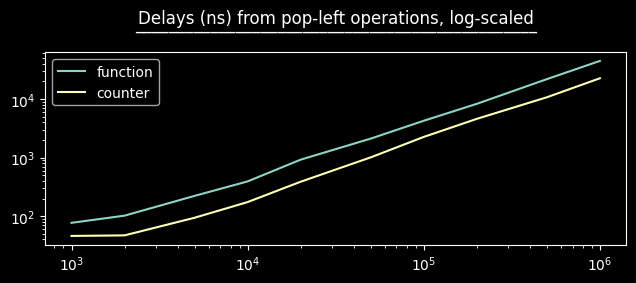

In [124]:
# Exercise 5 – implement top_k_frequencies
from numpy.random import randint
from collections import Counter
from typing import Iterable
import time

def count(data: Iterable, top: int = 1):
    counters = dict()
    for value in data:
        if value not in counters:
            counters[value] = 0
        counters[value] += 1
    counters = sorted((b, a) for a, b in counters.items())
    return [(b, a) for a, b in counters[:: -1][: top]]

top = 4
result = {"function": 0, "counter": 0, "diff": 0, "result": None}
sizes = [1e3, 2e3, 5e3, 1e4, 2e4, 5e4, 1e5, 2e5, 5e5, 1e6]
data = [*map(int, randint(0, 100, int(max(sizes))))]
results = {int(n): result.copy() for n in sizes}
for size, result in results.items():
    t = time.perf_counter()
    r1 = sorted(count(data[: size], top))
    d1 = int((time.perf_counter() - t) * 1e6)
    t = time.perf_counter()
    r2 = sorted(Counter(data[: size]).most_common(top))
    d2 = int((time.perf_counter() - t) * 1e6)
    result.update(function = d1, counter = d2, diff = 1 - d2 / d1)
    match = zip(r1, r2)
    if any([a != b for a, b in match]): continue
    result["result"] = r1

df = pandas.DataFrame.from_dict(results, orient = "index")
title = "Delays (ns) from pop-left operations, log-scaled"
title = title + "\n" + "\u203E" * int(len(title))

mean_diff = df.pop("diff").mean() * 100
df.plot(figsize = (7.5, 2.5), logx = True, logy = True, title = title);
display(df, f"Mean difference: {mean_diff:.2f}%")

## Exercise 6 – Simple LRU Cache with OrderedDict

**Goal**: Implement a small LRU cache using `collections.OrderedDict`.

**Requirements**:

- Implement class `LRUCache` with:
  - `__init__(self, capacity: int)`.
  - `get(self, key, default=None)` that returns the value and marks key as recent.
  - `put(self, key, value)` that inserts/updates and evicts least-recently-used
    when capacity is exceeded.
- Internally use `OrderedDict` and `move_to_end` / `popitem(last=False)`.

**Hint**: This mirrors the code in `g_collections.ipynb` but you should write it yourself.


In [195]:
# Exercise 6 – implement LRUCache

from collections import OrderedDict
from typing import Hashable, Any
import numpy

class LRUCache:
    def __init__(self, capacity: int):
        # TODO: initialize capacity and underlying OrderedDict
        self.capacity = capacity
        self.cache = OrderedDict()

    def get(self, key: Hashable, default: Any = None) -> Any:
        # TODO: return value and mark key as recently used
        value = self.cache.get(key, default)
        self.cache.move_to_end(key, last = True)
        return value

    def put(self, key: Hashable, value: Any) -> None:
        # TODO: insert/update and evict if over capacity
        if (len(self.cache) >= self.capacity):
            self.cache.popitem(last = False)
        self.cache[key] = value
        self.cache.move_to_end(key, last = True)

    def __repr__(self):
        return repr(dict(self.cache))

# Demo idea:
n_steps, step_size, overlap = 5, 3, 2
n_items = step_size * (n_steps + 1)
cache = LRUCache(capacity := 2 * step_size)
items = numpy.random.randint(1e3, 1e4, n_items)
r1 = range(0, n_steps * step_size, step_size)
for n1 in r1:
    r2 = [*range(n1, n1 + step_size + 1)]
    r3 = [*range(n1, n1 + overlap)][:: -1]
    for n2 in r2: cache.put(n2, int(items[n2]))
    print(f"Put: {str(r2):16} ==> LRU = {cache}")
    for n3 in r3: cache.get(n3)
    print(f"Get: {str(r3):16} ==> LRU = {cache}")

Put: [0, 1, 2, 3]     ==> LRU = {0: 2154, 1: 2523, 2: 3620, 3: 9314}
Get: [1, 0]           ==> LRU = {2: 3620, 3: 9314, 1: 2523, 0: 2154}
Put: [3, 4, 5, 6]     ==> LRU = {1: 2523, 0: 2154, 3: 9314, 4: 1163, 5: 2118, 6: 5494}
Get: [4, 3]           ==> LRU = {1: 2523, 0: 2154, 5: 2118, 6: 5494, 4: 1163, 3: 9314}
Put: [6, 7, 8, 9]     ==> LRU = {4: 1163, 3: 9314, 6: 5494, 7: 3064, 8: 3579, 9: 2803}
Get: [7, 6]           ==> LRU = {4: 1163, 3: 9314, 8: 3579, 9: 2803, 7: 3064, 6: 5494}
Put: [9, 10, 11, 12]  ==> LRU = {7: 3064, 6: 5494, 9: 2803, 10: 1439, 11: 4253, 12: 8884}
Get: [10, 9]          ==> LRU = {7: 3064, 6: 5494, 11: 4253, 12: 8884, 10: 1439, 9: 2803}
Put: [12, 13, 14, 15] ==> LRU = {10: 1439, 9: 2803, 12: 8884, 13: 5436, 14: 5302, 15: 7949}
Get: [13, 12]         ==> LRU = {10: 1439, 9: 2803, 14: 5302, 15: 7949, 13: 5436, 12: 8884}


## Exercise 7 – Min-Heap Priority Queue

**Goal**: Wrap `heapq` in a small `MinHeap` class as in the guide.

**Requirements**:

- Implement `class MinHeap` with:
  - `__init__(self, items: list[int] | None = None)` using `heapq.heapify`.
  - `push(self, value: int) -> None`.
  - `pop(self) -> int`.
  - `peek(self) -> int` (look at smallest without removing).
  - `__len__` so `len(heap)` works.
- Demo: push some `(priority, name)` pairs and pop them in order.

**Hint**: The underlying heap is just a list attribute.


,py_sort,heaping,heapsort
100,7,103,134
200,10,5,48
500,24,9,108
1000,49,17,222
2000,105,32,466
5000,282,89,1208
10000,571,172,2496
20000,1140,386,5148
50000,3025,910,13536
100000,6163,1789,28024


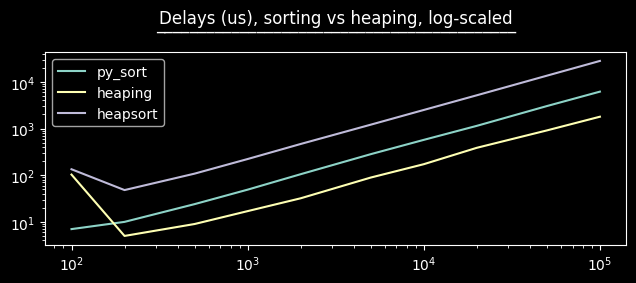

In [232]:
# Exercise 7 – implement MinHeap wrapper

import heapq, time, numpy
from typing import List

class MinHeap:
    def __init__(self, items: List[int] | None = None):
        # TODO: store list and heapify if items given
        if bool(items): self.items = list(items)
        else: self.items = list()
        heapq.heapify(self.items)

    def push(self, value: int) -> None: heapq.heappush(self.items, value)
    def pop(self) -> int: return heapq.heappop(self.items)
    def peek(self) -> int: return self.items[0]
    def __len__(self) -> int: return len(self.items)
    def __bool__(self) -> bool: return (len(self) > 0)

# Demo idea:
result = {"py_sort": 0, "heaping": 0, "heapsort": 0}
sizes = [1e2, 2e2, 5e2, 1e3, 2e3, 5e3, 1e4, 2e4, 5e4, 1e5]
data = [*map(int, randint(0, 100, int(max(sizes))))]
results = {int(n): result.copy() for n in sizes}
for size, result in results.items():
    array = data[: size]
    t = time.perf_counter()
    sorted(array)
    d1 = int((time.perf_counter() - t) * 1e6)
    t = time.perf_counter()
    min_heap = MinHeap(array)
    d2 = int((time.perf_counter() - t) * 1e6)
    while min_heap: min_heap.pop()
    d3 = int((time.perf_counter() - t) * 1e6)
    result.update(py_sort = d1, heaping = d2, heapsort = d3)

df = pandas.DataFrame.from_dict(results, orient = "index")
title = "Delays (us), sorting vs heaping, log-scaled"
title = title + "\n" + "\u203E" * int(len(title))
display(df)
df.plot(figsize = (7.5, 2.5), logx = True, logy = True, title = title);

## Exercise 8 – Top-k Elements with heapq

**Goal**: Use a min-heap of fixed size k to find the k largest elements.

**Requirements**:

- Implement `top_k(nums: list[int], k: int) -> list[int]`.
- Use `heapq` directly (not `nlargest`), maintaining a heap of size at most k.
- Return the k largest elements in **descending** order.

**Hint**: Push first k items, then for each remaining item, `heappushpop` if the
item is larger than the smallest in the heap.


In [ ]:
# Exercise 8 – implement top_k

import heapq
from typing import List
from collections import deque

def top_k(nums: list[int], k: int) -> List[int]:
    # TODO: maintain a min-heap of size k
    heapq.heapify(nums := nums.copy())
    results = deque(maxlen = k)
    for n in range(len(nums)):
        value = heapq.heappop(nums)
        results.appendleft(value)
    return results

# Demo idea:
print(top_k([5,1,9,3,7], 3))  # should be [9,7,5]

deque([9, 7, 5], maxlen=3)


## Exercise 9 – Build Graph Adjacency List

**Goal**: Represent an undirected graph using an adjacency list.

**Requirements**:

- Write `build_graph(edges: list[tuple[str, str]]) -> dict[str, list[str]]`.
- Use `defaultdict(list)` internally.
- Add edges in both directions (u->v and v->u).
- Demo with a small list of edges.

**Hint**: For each `(u, v)` in edges, append to both `g[u]` and `g[v]`.


In [244]:
# Exercise 9 – implement build_graph

from collections import defaultdict
from typing import Dict, List, Tuple

Graph = Dict[str, list[str]]

def build_graph(edges: list[Tuple[str, str]]) -> Graph:
    # TODO: use defaultdict(list) to build adjacency list
    graph = defaultdict(set)
    for node_1, node_2 in edges:
        graph[node_1].add(node_2)
        graph[node_2].add(node_1)
    return graph

# Demo idea:
graph = build_graph([("A", "B"), ("A", "C"), ("B", "D")])
for node, nodes in graph.items():
    print(f"-> Node \"{node}\" connects to {sorted(nodes)}")

-> Node "A" connects to ['B', 'C']
-> Node "B" connects to ['A', 'D']
-> Node "C" connects to ['A']
-> Node "D" connects to ['B']


## Exercise 10 – BFS and DFS on a Graph

**Goal**: Implement BFS and DFS using the adjacency list from Exercise 9.

**Requirements**:

- Implement `bfs(graph: Graph, start: str) -> list[str]` using a `deque`.
- Implement `dfs(graph: Graph, start: str) -> list[str]` using an explicit stack.
- Both should return the order of visited nodes.

**Hint**: Follow the patterns from `g_collections.ipynb`.


In [268]:
# Exercise 10 – implement bfs and dfs

from collections import deque
from typing import List

def bfs(graph: Graph, start: str) -> list[str]:
    visited = {start}
    order = list()
    queue = deque(visited)
    while len(queue) > 0:
        current_node = queue.popleft()
        next_nodes = graph[current_node]
        order.append(current_node)
        for node in next_nodes:
            if node in visited: continue
            queue.append(node)
            visited.add(node)
    return order

def dfs(graph: Graph, start: str) -> list[str]:
    return _dfs(graph, start, visited = set())
def _dfs(graph: Graph, prev_node: str, visited: set):
    next_nodes = graph.get(prev_node, set())
    order = [prev_node]
    visited.add(prev_node)
    for node in next_nodes:
        if node in visited: continue
        order.extend(_dfs(graph, node, visited))
    return order

# Demo idea (after implementing build_graph):
g = build_graph([("A","B"), ("A","C"), ("B","D"), ("C","E")])
print("BFS:", bfs(g, "A"))
print("DFS:", dfs(g, "A"))

BFS: ['A', 'C', 'B', 'E', 'D']
DFS: ['A', 'C', 'E', 'B', 'D']


## Exercise 11 – Shortest Path with networkx (optional)

**Goal**: Use `networkx` (if installed) to compute shortest paths and centrality.

**Requirements**:

- Inside a `try/except ImportError` block, import `networkx as nx`.
- Build a small weighted directed graph (3–5 nodes) with a `weight` attribute
  on each edge.
- Use `nx.dijkstra_path` and `nx.dijkstra_path_length` to get the shortest
  path between two nodes.
- Compute `nx.degree_centrality` or `nx.betweenness_centrality` for the
  unweighted version of the graph and print the results.

**Hint**: Mirror the patterns shown in the guide; keep the graph small.


In [288]:
# Exercise 11 – use networkx for shortest path (optional)

import networkx, pandas

G = networkx.Graph()
G.add_edge("A", "B", weight = 40)
G.add_edge("A", "C", weight = 2)
G.add_edge("B", "D", weight = 3)
G.add_edge("C", "D", weight = 1)
print("nodes:", [*G.nodes()]), print("edges:", [*G.edges()])
path = networkx.shortest_path(G, "A", "D", weight = "weight")
print("networkx.shortest_path(A -> D) =", path)
path = networkx.dijkstra_path(G, "A", "D", weight = "weight")
print("networkx.dijkstra_path(A -> D) =", path)
w = networkx.dijkstra_path_length(G, "A", "D", weight = "weight")
print("networkx.dijkstra_path_weight(A -> D) =", w)
gdc = pandas.Series(networkx.degree_centrality(G)).round(4)
gbc = pandas.Series(networkx.betweenness_centrality(G)).round(4)
print("networkx.degree_centrality =", gdc.to_dict())
print("networkx.betweenness_centrality:", gbc.to_dict())

nodes: ['A', 'B', 'C', 'D']
edges: [('A', 'B'), ('A', 'C'), ('B', 'D'), ('C', 'D')]
networkx.shortest_path(A -> D) = ['A', 'C', 'D']
networkx.dijkstra_path(A -> D) = ['A', 'C', 'D']
networkx.dijkstra_path_weight(A -> D) = 3
networkx.degree_centrality = {'A': 0.6667, 'B': 0.6667, 'C': 0.6667, 'D': 0.6667}
networkx.betweenness_centrality: {'A': 0.1667, 'B': 0.1667, 'C': 0.1667, 'D': 0.1667}


## Exercise 12 – Range Query with bisect

**Goal**: Use `bisect` to implement efficient range queries on a sorted list.

**Requirements**:

- Implement `range_query(sorted_values: list[int], lo: int, hi: int) -> list[int]`.
- Return all values `v` such that `lo <= v < hi`.
- Use `bisect_left` on `lo` and `hi` to find the slice bounds.

**Hint**: Do not scan linearly; rely on `bisect` indices and slicing.


In [378]:
# Exercise 12 – implement range_query

import bisect, numpy

def range_query(values: list[int], lo: int, hi: int) -> list[int]:
    # TODO: use bisect.bisect_left to find left/right indices and slice
    values_sorted = list()
    for value in values: bisect.insort(values_sorted, value)
    i1 = bisect.bisect_left(values_sorted, lo)
    i2 = bisect.bisect_right(values_sorted, hi)
    return values_sorted[i1 : i2]

# Demo idea:
values = numpy.random.randint(100, 1000, 10)
print("Values:", values := sorted(map(int, values)))
result = range_query(values, lo := 300, hi := 700)
print(f"Between {lo} and {hi}:", result)

Values: [160, 310, 369, 544, 616, 636, 641, 716, 750, 841]
Between 300 and 700: [310, 369, 544, 616, 636, 641]


## Exercise 13 – Weighted Random Choice with bisect

**Goal**: Use prefix sums + `bisect` to implement weighted random choice.

**Requirements**:

- Implement `weighted_choice(values: list[str], weights: list[float]) -> str`.
- Build a list of prefix sums from `weights`.
- Draw a random number `r` in `[0, total_weight)` and use `bisect_left` on the
  prefix sums to choose an index.

**Hint**: Use `itertools.accumulate` or manual accumulation; use `random.random()`.


In [349]:
# Exercise 13 – implement weighted_choice

import bisect, random
from itertools import accumulate
from collections import Counter
from typing import List

def wchoice(weights: dict[str, float]) -> str:
    prefix_sums = list(accumulate(weights.values()))
    r = random.random() * prefix_sums[-1]
    idx = bisect.bisect_left(prefix_sums, r)
    return [*weights.keys()][idx]

# Demo idea:
N, weights = 10_000, {"A": 0.1, "B": 0.3, "C": 0.6}
counts = Counter(wchoice(weights) for _ in range(N))
error = {k: round(1 - v / N / weights[k], 4) for k, v in counts.items()}
print("Count:", dict(counts)) ; print("Error:", error)

Count: {'C': 5943, 'B': 2996, 'A': 1061}
Error: {'C': 0.0095, 'B': 0.0013, 'A': -0.061}


## Exercise 14 – SortedList for Running Median (optional)

**Goal**: If `sortedcontainers` is installed, use `SortedList` to compute a
running median over a stream of numbers.

**Requirements**:

- Inside a `try/except ImportError` block, import `SortedList`.
- Implement `RunningMedian` with methods:
  - `add(value: float) -> float` returning the current median.
- Use a `SortedList` internally; median is middle element(s).

**Hint**: For even length, you can average the two middle elements.


In [308]:
# Exercise 14 – RunningMedian with SortedList (optional)
import numpy
from sortedcontainers import SortedList

class RunningMedian(SortedList):
    def __init__(self, maxlen: int = None):
        self.maxlen, self.value = maxlen, 0
        super().__init__()

    def add(self, value: float) -> float:
        # TODO: insert into SortedList and return median
        if (len(self) == self.maxlen): self.pop(0)
        super().add(value)
        if len(self) == 0: return None
        elif len(self) == 1: return self[0]
        else: midpoint = len(self) // 2
        return (self[midpoint - 1] + self[midpoint]) / 2

    def __repr__(self): return str([*self])

# Demo idea:
rm = RunningMedian()
values = numpy.random.randint(0, 1000, 20)
for value in map(int, values): print(
    f"med = {rm.add(value):.1f} ... \"{value:3}\" => {rm}")

med = 334.0 ... "334" => [334]
med = 315.0 ... "296" => [296, 334]
med = 315.0 ... "969" => [296, 334, 969]
med = 612.5 ... "891" => [296, 334, 891, 969]
med = 586.0 ... "838" => [296, 334, 838, 891, 969]
med = 726.0 ... "614" => [296, 334, 614, 838, 891, 969]
med = 668.5 ... "723" => [296, 334, 614, 723, 838, 891, 969]
med = 668.5 ... "114" => [114, 296, 334, 614, 723, 838, 891, 969]
med = 620.0 ... "626" => [114, 296, 334, 614, 626, 723, 838, 891, 969]
med = 620.0 ... "344" => [114, 296, 334, 344, 614, 626, 723, 838, 891, 969]
med = 612.0 ... "610" => [114, 296, 334, 344, 610, 614, 626, 723, 838, 891, 969]
med = 612.0 ... "103" => [103, 114, 296, 334, 344, 610, 614, 626, 723, 838, 891, 969]
med = 612.0 ... "846" => [103, 114, 296, 334, 344, 610, 614, 626, 723, 838, 846, 891, 969]
med = 620.0 ... "872" => [103, 114, 296, 334, 344, 610, 614, 626, 723, 838, 846, 872, 891, 969]
med = 620.0 ... "775" => [103, 114, 296, 334, 344, 610, 614, 626, 723, 775, 838, 846, 872, 891, 969]
med = 648.

## Exercise 15 – SortedDict Order Book Sketch (optional)

**Goal**: Use `SortedDict` (if available) to sketch a simple limit-order-book
like structure: price levels mapped to total size, always kept in sorted
order by price.

**Requirements**:

- Inside a `try/except ImportError` block, import `SortedDict`.
- Implement `add_order(book, price, size)` that adds `size` at `price`.
- Implement `best_price(book)` that returns the lowest price key.
- Demo by adding a few price levels and printing the book and best price.

**Hint**: For `SortedDict`, the keys are kept sorted; you can use
`book.peekitem(0)` to get the smallest key/value.


In [318]:
# Exercise 15 – SortedDict order book sketch (optional)

from sortedcontainers import SortedDict

def best_price(book: SortedDict[float, float]) -> float:
    # TODO: return the lowest price key
    return book.peekitem(0)[0]

def add_order(book: SortedDict[float, float], price: float, size: float) -> None:
    # TODO: increase size at this price level
    if (price == 0): price = best_price(book)
    if price not in book: book[price] = 0
    book[price] = book[price] + size
    if (book[price] <= 0): book.pop(price)

# Demo idea:
book = SortedDict()
add_order(book, 101.5, 2)
add_order(book, 100.0, 5)
add_order(book, 102.0, 1)
add_order(book, 100.0, -4)
add_order(book, 0, -1)
print(dict(book.items()))
print("Best price:", best_price(book))

{101.5: 2, 102.0: 1}
Best price: 101.5
